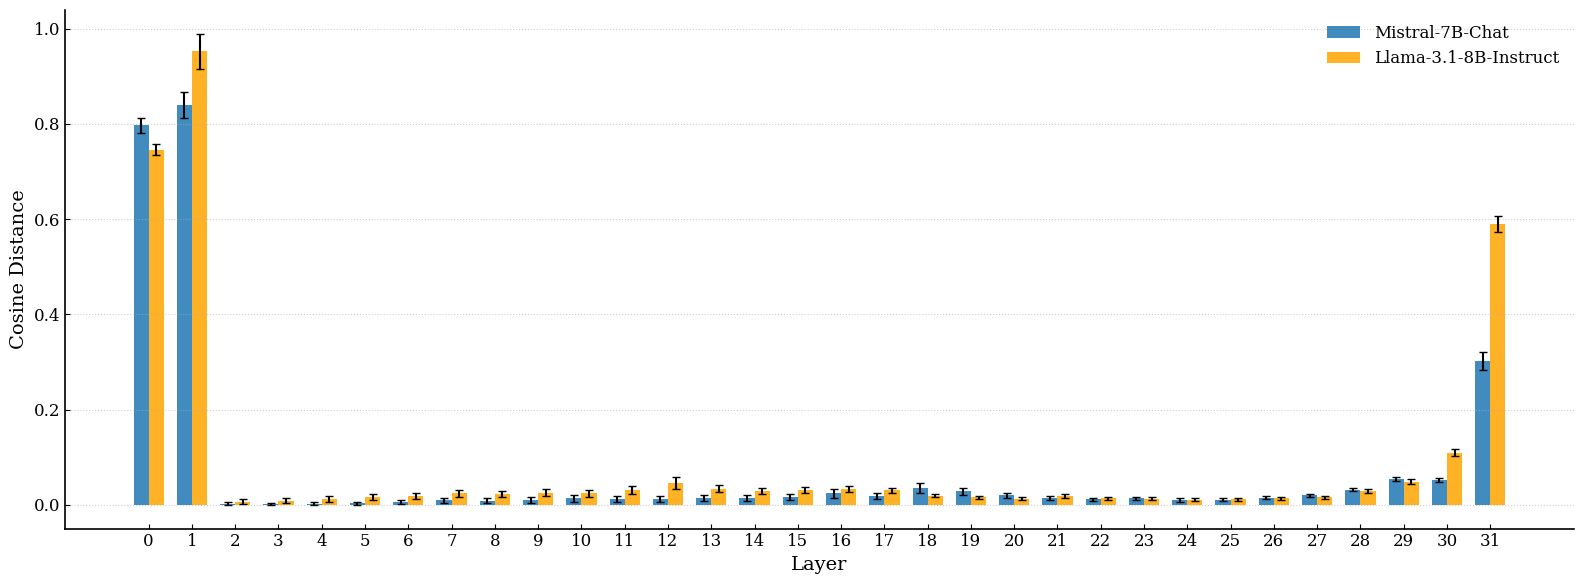

In [49]:
import matplotlib.pyplot as plt
import numpy as np
import re

# Your raw text data
mistral_data_raw = """
[Layer:] 0 | Cosine Distance [Mean:] 0.7969 [Std:] 0.0162
[Layer:] 1 | Cosine Distance [Mean:] 0.8398 [Std:] 0.0272
[Layer:] 2 | Cosine Distance [Mean:] 0.0020 [Std:] 0.0027
[Layer:] 3 | Cosine Distance [Mean:] 0.0015 [Std:] 0.0020
[Layer:] 4 | Cosine Distance [Mean:] 0.0021 [Std:] 0.0027
[Layer:] 5 | Cosine Distance [Mean:] 0.0031 [Std:] 0.0034
[Layer:] 6 | Cosine Distance [Mean:] 0.0054 [Std:] 0.0046
[Layer:] 7 | Cosine Distance [Mean:] 0.0088 [Std:] 0.0054
[Layer:] 8 | Cosine Distance [Mean:] 0.0087 [Std:] 0.0053
[Layer:] 9 | Cosine Distance [Mean:] 0.0095 [Std:] 0.0056
[Layer:] 10 | Cosine Distance [Mean:] 0.0135 [Std:] 0.0077
[Layer:] 11 | Cosine Distance [Mean:] 0.0122 [Std:] 0.0067
[Layer:] 12 | Cosine Distance [Mean:] 0.0117 [Std:] 0.0067
[Layer:] 13 | Cosine Distance [Mean:] 0.0135 [Std:] 0.0066
[Layer:] 14 | Cosine Distance [Mean:] 0.0130 [Std:] 0.0063
[Layer:] 15 | Cosine Distance [Mean:] 0.0156 [Std:] 0.0067
[Layer:] 16 | Cosine Distance [Mean:] 0.0238 [Std:] 0.0092
[Layer:] 17 | Cosine Distance [Mean:] 0.0181 [Std:] 0.0064
[Layer:] 18 | Cosine Distance [Mean:] 0.0342 [Std:] 0.0105
[Layer:] 19 | Cosine Distance [Mean:] 0.0283 [Std:] 0.0074
[Layer:] 20 | Cosine Distance [Mean:] 0.0193 [Std:] 0.0056
[Layer:] 21 | Cosine Distance [Mean:] 0.0133 [Std:] 0.0040
[Layer:] 22 | Cosine Distance [Mean:] 0.0112 [Std:] 0.0037
[Layer:] 23 | Cosine Distance [Mean:] 0.0131 [Std:] 0.0040
[Layer:] 24 | Cosine Distance [Mean:] 0.0098 [Std:] 0.0036
[Layer:] 25 | Cosine Distance [Mean:] 0.0102 [Std:] 0.0035
[Layer:] 26 | Cosine Distance [Mean:] 0.0150 [Std:] 0.0034
[Layer:] 27 | Cosine Distance [Mean:] 0.0198 [Std:] 0.0034
[Layer:] 28 | Cosine Distance [Mean:] 0.0315 [Std:] 0.0038
[Layer:] 29 | Cosine Distance [Mean:] 0.0542 [Std:] 0.0042
[Layer:] 30 | Cosine Distance [Mean:] 0.0527 [Std:] 0.0041
[Layer:] 31 | Cosine Distance [Mean:] 0.3027 [Std:] 0.0188
"""

llama_data_raw = """
[Layer:] 0 | Cosine Distance [Mean:] 0.7461 [Std:] 0.0116
[Layer:] 1 | Cosine Distance [Mean:] 0.9531 [Std:] 0.0369
[Layer:] 2 | Cosine Distance [Mean:] 0.0063 [Std:] 0.0047
[Layer:] 3 | Cosine Distance [Mean:] 0.0086 [Std:] 0.0048
[Layer:] 4 | Cosine Distance [Mean:] 0.0125 [Std:] 0.0059
[Layer:] 5 | Cosine Distance [Mean:] 0.0156 [Std:] 0.0065
[Layer:] 6 | Cosine Distance [Mean:] 0.0179 [Std:] 0.0069
[Layer:] 7 | Cosine Distance [Mean:] 0.0237 [Std:] 0.0081
[Layer:] 8 | Cosine Distance [Mean:] 0.0219 [Std:] 0.0067
[Layer:] 9 | Cosine Distance [Mean:] 0.0253 [Std:] 0.0077
[Layer:] 10 | Cosine Distance [Mean:] 0.0242 [Std:] 0.0075
[Layer:] 11 | Cosine Distance [Mean:] 0.0308 [Std:] 0.0088
[Layer:] 12 | Cosine Distance [Mean:] 0.0459 [Std:] 0.0125
[Layer:] 13 | Cosine Distance [Mean:] 0.0337 [Std:] 0.0081
[Layer:] 14 | Cosine Distance [Mean:] 0.0286 [Std:] 0.0062
[Layer:] 15 | Cosine Distance [Mean:] 0.0309 [Std:] 0.0073
[Layer:] 16 | Cosine Distance [Mean:] 0.0339 [Std:] 0.0063
[Layer:] 17 | Cosine Distance [Mean:] 0.0298 [Std:] 0.0055
[Layer:] 18 | Cosine Distance [Mean:] 0.0189 [Std:] 0.0037
[Layer:] 19 | Cosine Distance [Mean:] 0.0156 [Std:] 0.0036
[Layer:] 20 | Cosine Distance [Mean:] 0.0128 [Std:] 0.0032
[Layer:] 21 | Cosine Distance [Mean:] 0.0179 [Std:] 0.0036
[Layer:] 22 | Cosine Distance [Mean:] 0.0131 [Std:] 0.0030
[Layer:] 23 | Cosine Distance [Mean:] 0.0122 [Std:] 0.0030
[Layer:] 24 | Cosine Distance [Mean:] 0.0106 [Std:] 0.0026
[Layer:] 25 | Cosine Distance [Mean:] 0.0111 [Std:] 0.0026
[Layer:] 26 | Cosine Distance [Mean:] 0.0135 [Std:] 0.0030
[Layer:] 27 | Cosine Distance [Mean:] 0.0159 [Std:] 0.0033
[Layer:] 28 | Cosine Distance [Mean:] 0.0281 [Std:] 0.0038
[Layer:] 29 | Cosine Distance [Mean:] 0.0483 [Std:] 0.0050
[Layer:] 30 | Cosine Distance [Mean:] 0.1094 [Std:] 0.0075
[Layer:] 31 | Cosine Distance [Mean:] 0.5898 [Std:] 0.0167
"""

def parse_data(raw_text):
    means = []
    stds = []
    for line in raw_text.strip().split('\n'):
        if line.strip():
            # Extract Mean and Std using regex
            match = re.search(r'\[Mean:\] ([\d.]+) \[Std:\] ([\d.]+)', line)
            if match:
                means.append(float(match.group(1)))
                stds.append(float(match.group(2)))
    return means, stds

# Parse the data
m_means, m_stds = parse_data(mistral_data_raw)
l_means, l_stds = parse_data(llama_data_raw)

# X-axis locations and bar width
layers = np.arange(len(m_means))
width = 0.35

# Apply academic styling
plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'DejaVu Serif'],
    'font.size': 12,              
    'axes.labelsize': 14,         
    'axes.titlesize': 14,
    'figure.figsize': (16.0, 6.0), # Wide figure to fit 32 layers side-by-side
    'axes.spines.top': False,     
    'axes.spines.right': False
})

fig, ax = plt.subplots()

# Create grouped bar charts with error bars. Note the `+ width/2` for LLaMA to prevent overlap.
rects1 = ax.bar(layers - width/2, m_means, width, yerr=m_stds, label='Mistral-7B-Chat', color='#1f77b4', capsize=3, alpha=0.85)
rects2 = ax.bar(layers + width/2, l_means, width, yerr=l_stds, label='Llama-3.1-8B-Instruct', color='orange', capsize=3, alpha=0.85)

# Formatting
ax.set_xlabel('Layer')
ax.set_ylabel('Cosine Distance')
ax.set_xticks(layers)
ax.set_xticklabels(layers)
ax.grid(True, linestyle=':', alpha=0.6, axis='y')

# Render the legend without a box frame, positioned in the top left
ax.legend(frameon=False, loc='upper right')

plt.tight_layout()
# plt.savefig('cosine_distance_comparison.pdf', dpi=300, bbox_inches='tight')
plt.show()

In [50]:
# Your raw text data
mistral_data_raw_power = """
[Layer:] 0 | Cosine Distance [Mean:] 0.9844 [Std:] 0.0052 | [Max:] 1.0000 [Min:] 0.9727
[Layer:] 1 | Cosine Distance [Mean:] 0.8711 [Std:] 0.1475 | [Max:] 1.2031 [Min:] 0.4609
[Layer:] 2 | Cosine Distance [Mean:] 0.8301 [Std:] 0.1760 | [Max:] 1.1328 [Min:] 0.5508
[Layer:] 3 | Cosine Distance [Mean:] 0.8223 [Std:] 0.1971 | [Max:] 1.1270 [Min:] 0.5469
[Layer:] 4 | Cosine Distance [Mean:] 0.8145 [Std:] 0.1942 | [Max:] 1.0996 [Min:] 0.5742
[Layer:] 5 | Cosine Distance [Mean:] 0.8164 [Std:] 0.1906 | [Max:] 1.0840 [Min:] 0.5977
[Layer:] 6 | Cosine Distance [Mean:] 0.8262 [Std:] 0.1801 | [Max:] 1.0703 [Min:] 0.6328
[Layer:] 7 | Cosine Distance [Mean:] 0.8125 [Std:] 0.1812 | [Max:] 1.0508 [Min:] 0.6250
[Layer:] 8 | Cosine Distance [Mean:] 0.8184 [Std:] 0.1805 | [Max:] 1.0547 [Min:] 0.6328
[Layer:] 9 | Cosine Distance [Mean:] 0.8203 [Std:] 0.1852 | [Max:] 1.0508 [Min:] 0.6289
[Layer:] 10 | Cosine Distance [Mean:] 0.8047 [Std:] 0.1950 | [Max:] 1.0449 [Min:] 0.6055
[Layer:] 11 | Cosine Distance [Mean:] 0.8262 [Std:] 0.1860 | [Max:] 1.0488 [Min:] 0.6406
[Layer:] 12 | Cosine Distance [Mean:] 0.8457 [Std:] 0.1873 | [Max:] 1.0625 [Min:] 0.6562
[Layer:] 13 | Cosine Distance [Mean:] 0.8613 [Std:] 0.1863 | [Max:] 1.0781 [Min:] 0.6719
[Layer:] 14 | Cosine Distance [Mean:] 0.8555 [Std:] 0.1758 | [Max:] 1.0547 [Min:] 0.6797
[Layer:] 15 | Cosine Distance [Mean:] 0.8633 [Std:] 0.1672 | [Max:] 1.0508 [Min:] 0.6953
[Layer:] 16 | Cosine Distance [Mean:] 0.8555 [Std:] 0.1682 | [Max:] 1.0352 [Min:] 0.6836
[Layer:] 17 | Cosine Distance [Mean:] 0.8711 [Std:] 0.1565 | [Max:] 1.0430 [Min:] 0.7109
[Layer:] 18 | Cosine Distance [Mean:] 0.8574 [Std:] 0.1530 | [Max:] 1.0254 [Min:] 0.7031
[Layer:] 19 | Cosine Distance [Mean:] 0.8516 [Std:] 0.1590 | [Max:] 1.0234 [Min:] 0.6875
[Layer:] 20 | Cosine Distance [Mean:] 0.8438 [Std:] 0.1599 | [Max:] 1.0195 [Min:] 0.6797
[Layer:] 21 | Cosine Distance [Mean:] 0.8418 [Std:] 0.1687 | [Max:] 1.0195 [Min:] 0.6641
[Layer:] 22 | Cosine Distance [Mean:] 0.8438 [Std:] 0.1737 | [Max:] 1.0312 [Min:] 0.6562
[Layer:] 23 | Cosine Distance [Mean:] 0.8379 [Std:] 0.1800 | [Max:] 1.0273 [Min:] 0.6562
[Layer:] 24 | Cosine Distance [Mean:] 0.8320 [Std:] 0.1882 | [Max:] 1.0352 [Min:] 0.6406
[Layer:] 25 | Cosine Distance [Mean:] 0.8320 [Std:] 0.1862 | [Max:] 1.0312 [Min:] 0.6406
[Layer:] 26 | Cosine Distance [Mean:] 0.8496 [Std:] 0.1834 | [Max:] 1.0410 [Min:] 0.6562
[Layer:] 27 | Cosine Distance [Mean:] 0.8535 [Std:] 0.1713 | [Max:] 1.0352 [Min:] 0.6797
[Layer:] 28 | Cosine Distance [Mean:] 0.8750 [Std:] 0.1655 | [Max:] 1.0449 [Min:] 0.7031
[Layer:] 29 | Cosine Distance [Mean:] 0.8906 [Std:] 0.1568 | [Max:] 1.0547 [Min:] 0.7344
[Layer:] 30 | Cosine Distance [Mean:] 0.8984 [Std:] 0.1271 | [Max:] 1.0371 [Min:] 0.7656
[Layer:] 31 | Cosine Distance [Mean:] 0.8828 [Std:] 0.1103 | [Max:] 1.0078 [Min:] 0.7656
"""

llama_data_raw_power = """
[Layer:] 0 | Cosine Distance [Mean:] 1.0156 [Std:] 0.0039 | [Max:] 1.0312 [Min:] 1.0078
[Layer:] 1 | Cosine Distance [Mean:] 0.8359 [Std:] 0.2097 | [Max:] 1.1523 [Min:] 0.4961
[Layer:] 2 | Cosine Distance [Mean:] 0.8125 [Std:] 0.2033 | [Max:] 1.0586 [Min:] 0.5781
[Layer:] 3 | Cosine Distance [Mean:] 0.8301 [Std:] 0.1832 | [Max:] 1.0293 [Min:] 0.6406
[Layer:] 4 | Cosine Distance [Mean:] 0.8457 [Std:] 0.1626 | [Max:] 1.0117 [Min:] 0.6797
[Layer:] 5 | Cosine Distance [Mean:] 0.8594 [Std:] 0.1414 | [Max:] 1.0098 [Min:] 0.7188
[Layer:] 6 | Cosine Distance [Mean:] 0.8633 [Std:] 0.1514 | [Max:] 1.0156 [Min:] 0.7109
[Layer:] 7 | Cosine Distance [Mean:] 0.8477 [Std:] 0.1527 | [Max:] 1.0039 [Min:] 0.6953
[Layer:] 8 | Cosine Distance [Mean:] 0.8457 [Std:] 0.1514 | [Max:] 1.0000 [Min:] 0.6914
[Layer:] 9 | Cosine Distance [Mean:] 0.8613 [Std:] 0.1421 | [Max:] 1.0117 [Min:] 0.7188
[Layer:] 10 | Cosine Distance [Mean:] 0.8594 [Std:] 0.1474 | [Max:] 1.0098 [Min:] 0.7109
[Layer:] 11 | Cosine Distance [Mean:] 0.8672 [Std:] 0.1399 | [Max:] 1.0098 [Min:] 0.7266
[Layer:] 12 | Cosine Distance [Mean:] 0.8789 [Std:] 0.1284 | [Max:] 1.0117 [Min:] 0.7500
[Layer:] 13 | Cosine Distance [Mean:] 0.8789 [Std:] 0.1194 | [Max:] 1.0020 [Min:] 0.7578
[Layer:] 14 | Cosine Distance [Mean:] 0.8965 [Std:] 0.1193 | [Max:] 1.0195 [Min:] 0.7734
[Layer:] 15 | Cosine Distance [Mean:] 0.8730 [Std:] 0.1283 | [Max:] 1.0059 [Min:] 0.7422
[Layer:] 16 | Cosine Distance [Mean:] 0.8672 [Std:] 0.1294 | [Max:] 1.0020 [Min:] 0.7344
[Layer:] 17 | Cosine Distance [Mean:] 0.8691 [Std:] 0.1380 | [Max:] 1.0117 [Min:] 0.7266
[Layer:] 18 | Cosine Distance [Mean:] 0.8516 [Std:] 0.1515 | [Max:] 1.0117 [Min:] 0.6953
[Layer:] 19 | Cosine Distance [Mean:] 0.8457 [Std:] 0.1648 | [Max:] 1.0195 [Min:] 0.6797
[Layer:] 20 | Cosine Distance [Mean:] 0.8398 [Std:] 0.1684 | [Max:] 1.0195 [Min:] 0.6641
[Layer:] 21 | Cosine Distance [Mean:] 0.8203 [Std:] 0.1820 | [Max:] 1.0156 [Min:] 0.6328
[Layer:] 22 | Cosine Distance [Mean:] 0.8086 [Std:] 0.1908 | [Max:] 1.0117 [Min:] 0.6133
[Layer:] 23 | Cosine Distance [Mean:] 0.8008 [Std:] 0.2028 | [Max:] 1.0176 [Min:] 0.5938
[Layer:] 24 | Cosine Distance [Mean:] 0.8047 [Std:] 0.2031 | [Max:] 1.0156 [Min:] 0.5938
[Layer:] 25 | Cosine Distance [Mean:] 0.8008 [Std:] 0.2014 | [Max:] 1.0098 [Min:] 0.5938
[Layer:] 26 | Cosine Distance [Mean:] 0.8125 [Std:] 0.2040 | [Max:] 1.0215 [Min:] 0.6016
[Layer:] 27 | Cosine Distance [Mean:] 0.8203 [Std:] 0.1959 | [Max:] 1.0273 [Min:] 0.6250
[Layer:] 28 | Cosine Distance [Mean:] 0.8281 [Std:] 0.1883 | [Max:] 1.0273 [Min:] 0.6406
[Layer:] 29 | Cosine Distance [Mean:] 0.8281 [Std:] 0.1810 | [Max:] 1.0137 [Min:] 0.6445
[Layer:] 30 | Cosine Distance [Mean:] 0.8516 [Std:] 0.1572 | [Max:] 1.0156 [Min:] 0.6953
[Layer:] 31 | Cosine Distance [Mean:] 0.8691 [Std:] 0.1281 | [Max:] 1.0020 [Min:] 0.7383
"""

In [51]:
# Your raw text data
mistral_data_raw_weal = """
[Layer:] 0 | Cosine Distance [Mean:] 1.0000 [Std:] 0.0047 | [Max:] 1.0078 [Min:] 0.9844
[Layer:] 1 | Cosine Distance [Mean:] 0.8750 [Std:] 0.1331 | [Max:] 1.1445 [Min:] 0.5625
[Layer:] 2 | Cosine Distance [Mean:] 0.8516 [Std:] 0.1741 | [Max:] 1.1367 [Min:] 0.5625
[Layer:] 3 | Cosine Distance [Mean:] 0.8281 [Std:] 0.1985 | [Max:] 1.1250 [Min:] 0.5391
[Layer:] 4 | Cosine Distance [Mean:] 0.8184 [Std:] 0.2070 | [Max:] 1.1133 [Min:] 0.5469
[Layer:] 5 | Cosine Distance [Mean:] 0.8125 [Std:] 0.2008 | [Max:] 1.0840 [Min:] 0.5625
[Layer:] 6 | Cosine Distance [Mean:] 0.8184 [Std:] 0.1880 | [Max:] 1.0684 [Min:] 0.6016
[Layer:] 7 | Cosine Distance [Mean:] 0.8027 [Std:] 0.1956 | [Max:] 1.0527 [Min:] 0.5820
[Layer:] 8 | Cosine Distance [Mean:] 0.8262 [Std:] 0.1935 | [Max:] 1.0664 [Min:] 0.6094
[Layer:] 9 | Cosine Distance [Mean:] 0.7988 [Std:] 0.2049 | [Max:] 1.0469 [Min:] 0.5781
[Layer:] 10 | Cosine Distance [Mean:] 0.7832 [Std:] 0.2161 | [Max:] 1.0410 [Min:] 0.5547
[Layer:] 11 | Cosine Distance [Mean:] 0.7949 [Std:] 0.2111 | [Max:] 1.0391 [Min:] 0.5781
[Layer:] 12 | Cosine Distance [Mean:] 0.8086 [Std:] 0.2057 | [Max:] 1.0430 [Min:] 0.5977
[Layer:] 13 | Cosine Distance [Mean:] 0.8242 [Std:] 0.2024 | [Max:] 1.0469 [Min:] 0.6172
[Layer:] 14 | Cosine Distance [Mean:] 0.8242 [Std:] 0.1952 | [Max:] 1.0391 [Min:] 0.6250
[Layer:] 15 | Cosine Distance [Mean:] 0.8359 [Std:] 0.1808 | [Max:] 1.0332 [Min:] 0.6523
[Layer:] 16 | Cosine Distance [Mean:] 0.8555 [Std:] 0.1839 | [Max:] 1.0508 [Min:] 0.6680
[Layer:] 17 | Cosine Distance [Mean:] 0.8535 [Std:] 0.1871 | [Max:] 1.0508 [Min:] 0.6641
[Layer:] 18 | Cosine Distance [Mean:] 0.8477 [Std:] 0.1849 | [Max:] 1.0391 [Min:] 0.6641
[Layer:] 19 | Cosine Distance [Mean:] 0.8594 [Std:] 0.1816 | [Max:] 1.0469 [Min:] 0.6758
[Layer:] 20 | Cosine Distance [Mean:] 0.8633 [Std:] 0.1757 | [Max:] 1.0430 [Min:] 0.6875
[Layer:] 21 | Cosine Distance [Mean:] 0.8594 [Std:] 0.1819 | [Max:] 1.0469 [Min:] 0.6797
[Layer:] 22 | Cosine Distance [Mean:] 0.8633 [Std:] 0.1861 | [Max:] 1.0566 [Min:] 0.6797
[Layer:] 23 | Cosine Distance [Mean:] 0.8691 [Std:] 0.1871 | [Max:] 1.0605 [Min:] 0.6797
[Layer:] 24 | Cosine Distance [Mean:] 0.8594 [Std:] 0.1909 | [Max:] 1.0547 [Min:] 0.6641
[Layer:] 25 | Cosine Distance [Mean:] 0.8555 [Std:] 0.1918 | [Max:] 1.0508 [Min:] 0.6602
[Layer:] 26 | Cosine Distance [Mean:] 0.8652 [Std:] 0.1921 | [Max:] 1.0625 [Min:] 0.6719
[Layer:] 27 | Cosine Distance [Mean:] 0.8613 [Std:] 0.1785 | [Max:] 1.0469 [Min:] 0.6797
[Layer:] 28 | Cosine Distance [Mean:] 0.8555 [Std:] 0.1694 | [Max:] 1.0273 [Min:] 0.6797
[Layer:] 29 | Cosine Distance [Mean:] 0.8516 [Std:] 0.1508 | [Max:] 1.0078 [Min:] 0.6992
[Layer:] 30 | Cosine Distance [Mean:] 0.8633 [Std:] 0.1383 | [Max:] 1.0098 [Min:] 0.7227
[Layer:] 31 | Cosine Distance [Mean:] 0.8613 [Std:] 0.1145 | [Max:] 0.9863 [Min:] 0.7383
"""

llama_data_raw_weal = """
[Layer:] 0 | Cosine Distance [Mean:] 1.0156 [Std:] 0.0036 | [Max:] 1.0312 [Min:] 1.0156
[Layer:] 1 | Cosine Distance [Mean:] 0.8418 [Std:] 0.1912 | [Max:] 1.1152 [Min:] 0.5469
[Layer:] 2 | Cosine Distance [Mean:] 0.8047 [Std:] 0.2083 | [Max:] 1.0508 [Min:] 0.5625
[Layer:] 3 | Cosine Distance [Mean:] 0.8242 [Std:] 0.1871 | [Max:] 1.0234 [Min:] 0.6172
[Layer:] 4 | Cosine Distance [Mean:] 0.8418 [Std:] 0.1597 | [Max:] 1.0117 [Min:] 0.6797
[Layer:] 5 | Cosine Distance [Mean:] 0.8418 [Std:] 0.1581 | [Max:] 1.0039 [Min:] 0.6797
[Layer:] 6 | Cosine Distance [Mean:] 0.8281 [Std:] 0.1644 | [Max:] 0.9961 [Min:] 0.6641
[Layer:] 7 | Cosine Distance [Mean:] 0.8477 [Std:] 0.1614 | [Max:] 1.0117 [Min:] 0.6797
[Layer:] 8 | Cosine Distance [Mean:] 0.8496 [Std:] 0.1590 | [Max:] 1.0117 [Min:] 0.6875
[Layer:] 9 | Cosine Distance [Mean:] 0.8789 [Std:] 0.1396 | [Max:] 1.0234 [Min:] 0.7383
[Layer:] 10 | Cosine Distance [Mean:] 0.8867 [Std:] 0.1354 | [Max:] 1.0215 [Min:] 0.7500
[Layer:] 11 | Cosine Distance [Mean:] 0.8867 [Std:] 0.1309 | [Max:] 1.0234 [Min:] 0.7578
[Layer:] 12 | Cosine Distance [Mean:] 0.8867 [Std:] 0.1317 | [Max:] 1.0195 [Min:] 0.7539
[Layer:] 13 | Cosine Distance [Mean:] 0.8496 [Std:] 0.1387 | [Max:] 0.9883 [Min:] 0.7109
[Layer:] 14 | Cosine Distance [Mean:] 0.8633 [Std:] 0.1374 | [Max:] 1.0000 [Min:] 0.7227
[Layer:] 15 | Cosine Distance [Mean:] 0.8398 [Std:] 0.1448 | [Max:] 0.9902 [Min:] 0.6953
[Layer:] 16 | Cosine Distance [Mean:] 0.8516 [Std:] 0.1409 | [Max:] 0.9941 [Min:] 0.7109
[Layer:] 17 | Cosine Distance [Mean:] 0.8457 [Std:] 0.1466 | [Max:] 0.9922 [Min:] 0.6953
[Layer:] 18 | Cosine Distance [Mean:] 0.8320 [Std:] 0.1563 | [Max:] 0.9922 [Min:] 0.6719
[Layer:] 19 | Cosine Distance [Mean:] 0.8301 [Std:] 0.1702 | [Max:] 1.0039 [Min:] 0.6562
[Layer:] 20 | Cosine Distance [Mean:] 0.8398 [Std:] 0.1673 | [Max:] 1.0078 [Min:] 0.6719
[Layer:] 21 | Cosine Distance [Mean:] 0.8145 [Std:] 0.1823 | [Max:] 1.0000 [Min:] 0.6289
[Layer:] 22 | Cosine Distance [Mean:] 0.8164 [Std:] 0.1803 | [Max:] 0.9980 [Min:] 0.6328
[Layer:] 23 | Cosine Distance [Mean:] 0.8066 [Std:] 0.1882 | [Max:] 0.9961 [Min:] 0.6172
[Layer:] 24 | Cosine Distance [Mean:] 0.8008 [Std:] 0.1923 | [Max:] 0.9961 [Min:] 0.6055
[Layer:] 25 | Cosine Distance [Mean:] 0.7969 [Std:] 0.1965 | [Max:] 0.9961 [Min:] 0.5938
[Layer:] 26 | Cosine Distance [Mean:] 0.8066 [Std:] 0.1906 | [Max:] 0.9980 [Min:] 0.6094
[Layer:] 27 | Cosine Distance [Mean:] 0.8047 [Std:] 0.1887 | [Max:] 0.9961 [Min:] 0.6172
[Layer:] 28 | Cosine Distance [Mean:] 0.8164 [Std:] 0.1768 | [Max:] 1.0000 [Min:] 0.6367
[Layer:] 29 | Cosine Distance [Mean:] 0.8320 [Std:] 0.1610 | [Max:] 0.9961 [Min:] 0.6719
[Layer:] 30 | Cosine Distance [Mean:] 0.8555 [Std:] 0.1376 | [Max:] 0.9961 [Min:] 0.7188
[Layer:] 31 | Cosine Distance [Mean:] 0.8730 [Std:] 0.1166 | [Max:] 0.9922 [Min:] 0.7539
"""

In [52]:
# Your raw text data
mistral_data_raw_corri = """
[Layer:] 0 | Cosine Distance [Mean:] 0.9883 [Std:] 0.0051 | [Max:] 1.0000 [Min:] 0.9727
[Layer:] 1 | Cosine Distance [Mean:] 0.9453 [Std:] 0.1213 | [Max:] 1.2266 [Min:] 0.5469
[Layer:] 2 | Cosine Distance [Mean:] 0.9121 [Std:] 0.1467 | [Max:] 1.1504 [Min:] 0.5938
[Layer:] 3 | Cosine Distance [Mean:] 0.8984 [Std:] 0.1687 | [Max:] 1.1582 [Min:] 0.6094
[Layer:] 4 | Cosine Distance [Mean:] 0.8691 [Std:] 0.1768 | [Max:] 1.1445 [Min:] 0.6055
[Layer:] 5 | Cosine Distance [Mean:] 0.8477 [Std:] 0.1860 | [Max:] 1.1309 [Min:] 0.5781
[Layer:] 6 | Cosine Distance [Mean:] 0.8594 [Std:] 0.1744 | [Max:] 1.1270 [Min:] 0.6328
[Layer:] 7 | Cosine Distance [Mean:] 0.8652 [Std:] 0.1688 | [Max:] 1.1172 [Min:] 0.6562
[Layer:] 8 | Cosine Distance [Mean:] 0.8574 [Std:] 0.1638 | [Max:] 1.0996 [Min:] 0.6602
[Layer:] 9 | Cosine Distance [Mean:] 0.8496 [Std:] 0.1719 | [Max:] 1.0938 [Min:] 0.6406
[Layer:] 10 | Cosine Distance [Mean:] 0.8574 [Std:] 0.1738 | [Max:] 1.0996 [Min:] 0.6562
[Layer:] 11 | Cosine Distance [Mean:] 0.8535 [Std:] 0.1774 | [Max:] 1.0977 [Min:] 0.6484
[Layer:] 12 | Cosine Distance [Mean:] 0.8535 [Std:] 0.1627 | [Max:] 1.0723 [Min:] 0.6641
[Layer:] 13 | Cosine Distance [Mean:] 0.8613 [Std:] 0.1546 | [Max:] 1.0605 [Min:] 0.6875
[Layer:] 14 | Cosine Distance [Mean:] 0.9062 [Std:] 0.1355 | [Max:] 1.0781 [Min:] 0.7578
[Layer:] 15 | Cosine Distance [Mean:] 0.8945 [Std:] 0.1283 | [Max:] 1.0508 [Min:] 0.7539
[Layer:] 16 | Cosine Distance [Mean:] 0.8750 [Std:] 0.1332 | [Max:] 1.0430 [Min:] 0.7344
[Layer:] 17 | Cosine Distance [Mean:] 0.9102 [Std:] 0.1180 | [Max:] 1.0488 [Min:] 0.7812
[Layer:] 18 | Cosine Distance [Mean:] 0.8926 [Std:] 0.1222 | [Max:] 1.0352 [Min:] 0.7695
[Layer:] 19 | Cosine Distance [Mean:] 0.8848 [Std:] 0.1210 | [Max:] 1.0254 [Min:] 0.7500
[Layer:] 20 | Cosine Distance [Mean:] 0.8809 [Std:] 0.1238 | [Max:] 1.0215 [Min:] 0.7500
[Layer:] 21 | Cosine Distance [Mean:] 0.8750 [Std:] 0.1321 | [Max:] 1.0293 [Min:] 0.7344
[Layer:] 22 | Cosine Distance [Mean:] 0.8789 [Std:] 0.1337 | [Max:] 1.0273 [Min:] 0.7344
[Layer:] 23 | Cosine Distance [Mean:] 0.8672 [Std:] 0.1465 | [Max:] 1.0312 [Min:] 0.7109
[Layer:] 24 | Cosine Distance [Mean:] 0.8711 [Std:] 0.1469 | [Max:] 1.0332 [Min:] 0.7109
[Layer:] 25 | Cosine Distance [Mean:] 0.8516 [Std:] 0.1500 | [Max:] 1.0195 [Min:] 0.6875
[Layer:] 26 | Cosine Distance [Mean:] 0.8652 [Std:] 0.1479 | [Max:] 1.0254 [Min:] 0.7070
[Layer:] 27 | Cosine Distance [Mean:] 0.8711 [Std:] 0.1457 | [Max:] 1.0273 [Min:] 0.7109
[Layer:] 28 | Cosine Distance [Mean:] 0.8633 [Std:] 0.1458 | [Max:] 1.0195 [Min:] 0.7031
[Layer:] 29 | Cosine Distance [Mean:] 0.8965 [Std:] 0.1275 | [Max:] 1.0332 [Min:] 0.7617
[Layer:] 30 | Cosine Distance [Mean:] 0.9199 [Std:] 0.1121 | [Max:] 1.0352 [Min:] 0.8008
[Layer:] 31 | Cosine Distance [Mean:] 0.9062 [Std:] 0.0876 | [Max:] 1.0059 [Min:] 0.8164
"""

llama_data_raw_corri = """
[Layer:] 0 | Cosine Distance [Mean:] 0.9961 [Std:] 0.0036 | [Max:] 1.0078 [Min:] 0.9883
[Layer:] 1 | Cosine Distance [Mean:] 0.8418 [Std:] 0.2026 | [Max:] 1.1602 [Min:] 0.5078
[Layer:] 2 | Cosine Distance [Mean:] 0.8418 [Std:] 0.1848 | [Max:] 1.0742 [Min:] 0.6328
[Layer:] 3 | Cosine Distance [Mean:] 0.8418 [Std:] 0.1790 | [Max:] 1.0430 [Min:] 0.6484
[Layer:] 4 | Cosine Distance [Mean:] 0.8633 [Std:] 0.1605 | [Max:] 1.0391 [Min:] 0.6992
[Layer:] 5 | Cosine Distance [Mean:] 0.8477 [Std:] 0.1619 | [Max:] 1.0195 [Min:] 0.6797
[Layer:] 6 | Cosine Distance [Mean:] 0.8457 [Std:] 0.1542 | [Max:] 1.0078 [Min:] 0.6875
[Layer:] 7 | Cosine Distance [Mean:] 0.8711 [Std:] 0.1526 | [Max:] 1.0312 [Min:] 0.7188
[Layer:] 8 | Cosine Distance [Mean:] 0.8418 [Std:] 0.1603 | [Max:] 1.0117 [Min:] 0.6797
[Layer:] 9 | Cosine Distance [Mean:] 0.8633 [Std:] 0.1614 | [Max:] 1.0352 [Min:] 0.6992
[Layer:] 10 | Cosine Distance [Mean:] 0.8477 [Std:] 0.1593 | [Max:] 1.0156 [Min:] 0.6875
[Layer:] 11 | Cosine Distance [Mean:] 0.8477 [Std:] 0.1555 | [Max:] 1.0078 [Min:] 0.6914
[Layer:] 12 | Cosine Distance [Mean:] 0.8223 [Std:] 0.1505 | [Max:] 0.9824 [Min:] 0.6719
[Layer:] 13 | Cosine Distance [Mean:] 0.8086 [Std:] 0.1596 | [Max:] 0.9766 [Min:] 0.6484
[Layer:] 14 | Cosine Distance [Mean:] 0.8262 [Std:] 0.1532 | [Max:] 0.9844 [Min:] 0.6719
[Layer:] 15 | Cosine Distance [Mean:] 0.8496 [Std:] 0.1397 | [Max:] 0.9922 [Min:] 0.7070
[Layer:] 16 | Cosine Distance [Mean:] 0.8320 [Std:] 0.1512 | [Max:] 0.9883 [Min:] 0.6797
[Layer:] 17 | Cosine Distance [Mean:] 0.8086 [Std:] 0.1548 | [Max:] 0.9648 [Min:] 0.6484
[Layer:] 18 | Cosine Distance [Mean:] 0.7812 [Std:] 0.1690 | [Max:] 0.9570 [Min:] 0.6094
[Layer:] 19 | Cosine Distance [Mean:] 0.7812 [Std:] 0.1721 | [Max:] 0.9590 [Min:] 0.6055
[Layer:] 20 | Cosine Distance [Mean:] 0.7754 [Std:] 0.1724 | [Max:] 0.9512 [Min:] 0.6016
[Layer:] 21 | Cosine Distance [Mean:] 0.7656 [Std:] 0.1807 | [Max:] 0.9492 [Min:] 0.5820
[Layer:] 22 | Cosine Distance [Mean:] 0.7578 [Std:] 0.1885 | [Max:] 0.9531 [Min:] 0.5625
[Layer:] 23 | Cosine Distance [Mean:] 0.7461 [Std:] 0.1959 | [Max:] 0.9453 [Min:] 0.5469
[Layer:] 24 | Cosine Distance [Mean:] 0.7695 [Std:] 0.1877 | [Max:] 0.9609 [Min:] 0.5781
[Layer:] 25 | Cosine Distance [Mean:] 0.7598 [Std:] 0.1979 | [Max:] 0.9609 [Min:] 0.5586
[Layer:] 26 | Cosine Distance [Mean:] 0.7676 [Std:] 0.1955 | [Max:] 0.9648 [Min:] 0.5703
[Layer:] 27 | Cosine Distance [Mean:] 0.7871 [Std:] 0.1865 | [Max:] 0.9766 [Min:] 0.6016
[Layer:] 28 | Cosine Distance [Mean:] 0.7852 [Std:] 0.1837 | [Max:] 0.9746 [Min:] 0.6016
[Layer:] 29 | Cosine Distance [Mean:] 0.8008 [Std:] 0.1760 | [Max:] 0.9785 [Min:] 0.6250
[Layer:] 30 | Cosine Distance [Mean:] 0.8457 [Std:] 0.1461 | [Max:] 0.9922 [Min:] 0.6992
[Layer:] 31 | Cosine Distance [Mean:] 0.8633 [Std:] 0.1291 | [Max:] 0.9922 [Min:] 0.7305
"""

In [53]:
# Your raw text data
mistral_data_raw_survival = """
[Layer:] 0 | Cosine Distance [Mean:] 1.0234 [Std:] 0.0055 | [Max:] 1.0391 [Min:] 1.0078
[Layer:] 1 | Cosine Distance [Mean:] 0.9238 [Std:] 0.1160 | [Max:] 1.1895 [Min:] 0.4844
[Layer:] 2 | Cosine Distance [Mean:] 0.8750 [Std:] 0.1570 | [Max:] 1.1543 [Min:] 0.5391
[Layer:] 3 | Cosine Distance [Mean:] 0.8281 [Std:] 0.1831 | [Max:] 1.1367 [Min:] 0.5391
[Layer:] 4 | Cosine Distance [Mean:] 0.8184 [Std:] 0.1825 | [Max:] 1.1094 [Min:] 0.5742
[Layer:] 5 | Cosine Distance [Mean:] 0.8203 [Std:] 0.1863 | [Max:] 1.1016 [Min:] 0.5859
[Layer:] 6 | Cosine Distance [Mean:] 0.8320 [Std:] 0.1779 | [Max:] 1.0938 [Min:] 0.6250
[Layer:] 7 | Cosine Distance [Mean:] 0.8066 [Std:] 0.1776 | [Max:] 1.0547 [Min:] 0.6016
[Layer:] 8 | Cosine Distance [Mean:] 0.8398 [Std:] 0.1794 | [Max:] 1.0898 [Min:] 0.6406
[Layer:] 9 | Cosine Distance [Mean:] 0.8418 [Std:] 0.1803 | [Max:] 1.0840 [Min:] 0.6484
[Layer:] 10 | Cosine Distance [Mean:] 0.8242 [Std:] 0.1831 | [Max:] 1.0645 [Min:] 0.6328
[Layer:] 11 | Cosine Distance [Mean:] 0.8184 [Std:] 0.1915 | [Max:] 1.0645 [Min:] 0.6172
[Layer:] 12 | Cosine Distance [Mean:] 0.8262 [Std:] 0.1855 | [Max:] 1.0586 [Min:] 0.6328
[Layer:] 13 | Cosine Distance [Mean:] 0.8340 [Std:] 0.1733 | [Max:] 1.0469 [Min:] 0.6562
[Layer:] 14 | Cosine Distance [Mean:] 0.8301 [Std:] 0.1640 | [Max:] 1.0254 [Min:] 0.6641
[Layer:] 15 | Cosine Distance [Mean:] 0.8633 [Std:] 0.1582 | [Max:] 1.0527 [Min:] 0.7031
[Layer:] 16 | Cosine Distance [Mean:] 0.8457 [Std:] 0.1603 | [Max:] 1.0332 [Min:] 0.6797
[Layer:] 17 | Cosine Distance [Mean:] 0.8359 [Std:] 0.1518 | [Max:] 1.0078 [Min:] 0.6797
[Layer:] 18 | Cosine Distance [Mean:] 0.8516 [Std:] 0.1521 | [Max:] 1.0215 [Min:] 0.6953
[Layer:] 19 | Cosine Distance [Mean:] 0.8438 [Std:] 0.1533 | [Max:] 1.0195 [Min:] 0.6875
[Layer:] 20 | Cosine Distance [Mean:] 0.8301 [Std:] 0.1557 | [Max:] 1.0098 [Min:] 0.6719
[Layer:] 21 | Cosine Distance [Mean:] 0.8242 [Std:] 0.1615 | [Max:] 1.0078 [Min:] 0.6602
[Layer:] 22 | Cosine Distance [Mean:] 0.8398 [Std:] 0.1612 | [Max:] 1.0254 [Min:] 0.6797
[Layer:] 23 | Cosine Distance [Mean:] 0.8359 [Std:] 0.1726 | [Max:] 1.0273 [Min:] 0.6602
[Layer:] 24 | Cosine Distance [Mean:] 0.8457 [Std:] 0.1727 | [Max:] 1.0352 [Min:] 0.6719
[Layer:] 25 | Cosine Distance [Mean:] 0.8516 [Std:] 0.1678 | [Max:] 1.0352 [Min:] 0.6797
[Layer:] 26 | Cosine Distance [Mean:] 0.8652 [Std:] 0.1706 | [Max:] 1.0469 [Min:] 0.6953
[Layer:] 27 | Cosine Distance [Mean:] 0.8750 [Std:] 0.1635 | [Max:] 1.0508 [Min:] 0.7070
[Layer:] 28 | Cosine Distance [Mean:] 0.8770 [Std:] 0.1567 | [Max:] 1.0352 [Min:] 0.7188
[Layer:] 29 | Cosine Distance [Mean:] 0.8867 [Std:] 0.1386 | [Max:] 1.0312 [Min:] 0.7500
[Layer:] 30 | Cosine Distance [Mean:] 0.9141 [Std:] 0.1262 | [Max:] 1.0449 [Min:] 0.7852
[Layer:] 31 | Cosine Distance [Mean:] 0.9297 [Std:] 0.1116 | [Max:] 1.0547 [Min:] 0.8125
"""

llama_data_raw_survival = """
[Layer:] 0 | Cosine Distance [Mean:] 1.0469 [Std:] 0.0045 | [Max:] 1.0625 [Min:] 1.0391
[Layer:] 1 | Cosine Distance [Mean:] 0.8457 [Std:] 0.1952 | [Max:] 1.1484 [Min:] 0.4922
[Layer:] 2 | Cosine Distance [Mean:] 0.8262 [Std:] 0.1923 | [Max:] 1.0586 [Min:] 0.5938
[Layer:] 3 | Cosine Distance [Mean:] 0.8301 [Std:] 0.1907 | [Max:] 1.0410 [Min:] 0.6250
[Layer:] 4 | Cosine Distance [Mean:] 0.8633 [Std:] 0.1607 | [Max:] 1.0312 [Min:] 0.6953
[Layer:] 5 | Cosine Distance [Mean:] 0.8750 [Std:] 0.1563 | [Max:] 1.0352 [Min:] 0.7148
[Layer:] 6 | Cosine Distance [Mean:] 0.9004 [Std:] 0.1407 | [Max:] 1.0469 [Min:] 0.7578
[Layer:] 7 | Cosine Distance [Mean:] 0.8965 [Std:] 0.1441 | [Max:] 1.0430 [Min:] 0.7500
[Layer:] 8 | Cosine Distance [Mean:] 0.8945 [Std:] 0.1543 | [Max:] 1.0508 [Min:] 0.7383
[Layer:] 9 | Cosine Distance [Mean:] 0.8887 [Std:] 0.1523 | [Max:] 1.0430 [Min:] 0.7344
[Layer:] 10 | Cosine Distance [Mean:] 0.9004 [Std:] 0.1483 | [Max:] 1.0508 [Min:] 0.7500
[Layer:] 11 | Cosine Distance [Mean:] 0.9102 [Std:] 0.1447 | [Max:] 1.0566 [Min:] 0.7656
[Layer:] 12 | Cosine Distance [Mean:] 0.8984 [Std:] 0.1494 | [Max:] 1.0508 [Min:] 0.7500
[Layer:] 13 | Cosine Distance [Mean:] 0.9062 [Std:] 0.1387 | [Max:] 1.0469 [Min:] 0.7656
[Layer:] 14 | Cosine Distance [Mean:] 0.9160 [Std:] 0.1302 | [Max:] 1.0469 [Min:] 0.7852
[Layer:] 15 | Cosine Distance [Mean:] 0.9160 [Std:] 0.1226 | [Max:] 1.0449 [Min:] 0.7930
[Layer:] 16 | Cosine Distance [Mean:] 0.9121 [Std:] 0.1272 | [Max:] 1.0449 [Min:] 0.7812
[Layer:] 17 | Cosine Distance [Mean:] 0.9004 [Std:] 0.1330 | [Max:] 1.0371 [Min:] 0.7656
[Layer:] 18 | Cosine Distance [Mean:] 0.8887 [Std:] 0.1450 | [Max:] 1.0371 [Min:] 0.7422
[Layer:] 19 | Cosine Distance [Mean:] 0.8906 [Std:] 0.1415 | [Max:] 1.0352 [Min:] 0.7500
[Layer:] 20 | Cosine Distance [Mean:] 0.8945 [Std:] 0.1459 | [Max:] 1.0410 [Min:] 0.7422
[Layer:] 21 | Cosine Distance [Mean:] 0.8848 [Std:] 0.1549 | [Max:] 1.0410 [Min:] 0.7266
[Layer:] 22 | Cosine Distance [Mean:] 0.8750 [Std:] 0.1585 | [Max:] 1.0391 [Min:] 0.7109
[Layer:] 23 | Cosine Distance [Mean:] 0.8633 [Std:] 0.1671 | [Max:] 1.0312 [Min:] 0.6953
[Layer:] 24 | Cosine Distance [Mean:] 0.8438 [Std:] 0.1728 | [Max:] 1.0195 [Min:] 0.6680
[Layer:] 25 | Cosine Distance [Mean:] 0.8477 [Std:] 0.1670 | [Max:] 1.0156 [Min:] 0.6758
[Layer:] 26 | Cosine Distance [Mean:] 0.8438 [Std:] 0.1669 | [Max:] 1.0156 [Min:] 0.6719
[Layer:] 27 | Cosine Distance [Mean:] 0.8418 [Std:] 0.1665 | [Max:] 1.0137 [Min:] 0.6719
[Layer:] 28 | Cosine Distance [Mean:] 0.8574 [Std:] 0.1585 | [Max:] 1.0156 [Min:] 0.6953
[Layer:] 29 | Cosine Distance [Mean:] 0.8672 [Std:] 0.1399 | [Max:] 1.0117 [Min:] 0.7266
[Layer:] 30 | Cosine Distance [Mean:] 0.8984 [Std:] 0.1179 | [Max:] 1.0195 [Min:] 0.7812
[Layer:] 31 | Cosine Distance [Mean:] 0.9297 [Std:] 0.0872 | [Max:] 1.0195 [Min:] 0.8398
"""

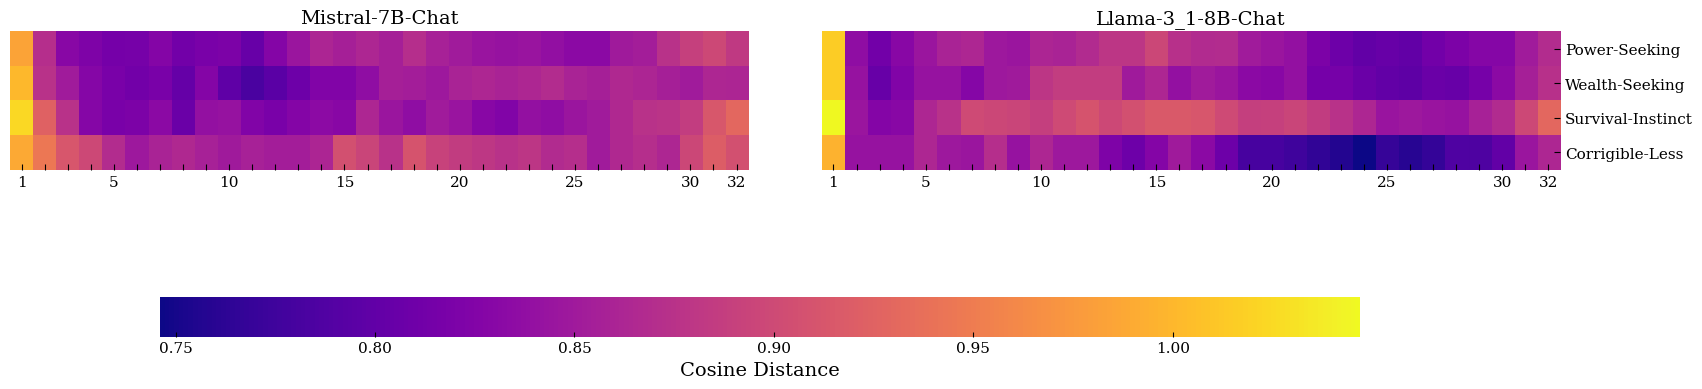

In [54]:
import matplotlib.pyplot as plt
import numpy as np
import re


# 2. BUILD THE DICTIONARY NOW THAT VARIABLES EXIST
RES = {
    'Power-Seeking': {
        'Mistral-7B-Chat': mistral_data_raw_power,
        'Llama-3_1-8B-Chat': llama_data_raw_power
    },
    'Wealth-Seeking': {
        'Mistral-7B-Chat': mistral_data_raw_weal,
        'Llama-3_1-8B-Chat': llama_data_raw_weal
    },
    'Survival-Instinct': {
        'Mistral-7B-Chat': mistral_data_raw_survival,
        'Llama-3_1-8B-Chat': llama_data_raw_survival
    },
    'Corrigible-Less': {
        'Mistral-7B-Chat': mistral_data_raw_corri,
        'Llama-3_1-8B-Chat': llama_data_raw_corri
    }
}

# 3. PARSE AND PLOT
def parse_means(raw_text):
    means = []
    for line in raw_text.strip().split('\n'):
        if line.strip():
            match = re.search(r'\[Mean:\] ([\d.]+)', line)
            if match:
                means.append(float(match.group(1)))
    return means

models = ['Mistral-7B-Chat', 'Llama-3_1-8B-Chat']
datasets = list(RES.keys())
num_layers = 32

model_heatmaps = {model: [] for model in models}

for dataset in datasets:
    for model in models:
        means = parse_means(RES[dataset][model])
        model_heatmaps[model].append(means)

for model in models:
    model_heatmaps[model] = np.array(model_heatmaps[model])

plt.rcParams.update({
    'font.family': 'serif', 
    'font.size': 11, 
    'axes.linewidth': 1.2,
    'xtick.direction': 'in', 
    'ytick.direction': 'in', 
    'grid.alpha': 0.3
})

fig, axes = plt.subplots(ncols=len(models), figsize=(20, 4))
if len(models) == 1:
    axes = [axes]

global_min = min(model_heatmaps[m].min() for m in models)
global_max = max(model_heatmaps[m].max() for m in models)

for i, (ax, model) in enumerate(zip(axes, models)):
    data = model_heatmaps[model]
    
    im = ax.imshow(data, aspect=1.5, cmap='plasma', vmin=global_min, vmax=global_max)

    
    ax.set_title(model, loc='center', fontweight='light')
    
    ax.set_yticks(np.arange(len(datasets)))
    
    if i == len(models) - 1:
        ax.set_yticklabels(datasets)
        ax.yaxis.tick_right()
        ax.tick_params(axis='y', length=4)
    else:
        ax.set_yticklabels([]) 
        ax.tick_params(axis='y', length=0) 

    ax.set_xticks(np.arange(num_layers))
    xtick_labels = []
    for j in range(num_layers):
        layer_num = j + 1
        if layer_num == 1 or layer_num % 5 == 0 or layer_num == 32:
            xtick_labels.append(str(layer_num))
        else:
            xtick_labels.append('')
            
    ax.set_xticklabels(xtick_labels)
    ax.tick_params(axis='x', length=4)
    
    for spine in ax.spines.values():
        spine.set_visible(False)

cbar_ax = fig.add_axes([0.2, -0.05, 0.6, 0.1]) 
cbar = fig.colorbar(im, cax=cbar_ax, orientation='horizontal')
cbar.set_label('Cosine Distance')
cbar.outline.set_visible(False)

plt.subplots_adjust(bottom=0.2, wspace=0.1)
plt.show()

# Steered

In [ ]:
# Your raw text data
mistral_data_raw_power = """
[Layer:] 0 | Cosine Distance [Mean:] 0.9844 [Std:] 0.0052 | [Max:] 1.0000 [Min:] 0.9727
[Layer:] 1 | Cosine Distance [Mean:] 0.8711 [Std:] 0.1475 | [Max:] 1.2031 [Min:] 0.4609
[Layer:] 2 | Cosine Distance [Mean:] 0.8301 [Std:] 0.1760 | [Max:] 1.1328 [Min:] 0.5508
[Layer:] 3 | Cosine Distance [Mean:] 0.8223 [Std:] 0.1971 | [Max:] 1.1270 [Min:] 0.5469
[Layer:] 4 | Cosine Distance [Mean:] 0.8145 [Std:] 0.1942 | [Max:] 1.0996 [Min:] 0.5742
[Layer:] 5 | Cosine Distance [Mean:] 0.8164 [Std:] 0.1906 | [Max:] 1.0840 [Min:] 0.5977
[Layer:] 6 | Cosine Distance [Mean:] 0.8262 [Std:] 0.1801 | [Max:] 1.0703 [Min:] 0.6328
[Layer:] 7 | Cosine Distance [Mean:] 0.8125 [Std:] 0.1812 | [Max:] 1.0508 [Min:] 0.6250
[Layer:] 8 | Cosine Distance [Mean:] 0.8184 [Std:] 0.1805 | [Max:] 1.0547 [Min:] 0.6328
[Layer:] 9 | Cosine Distance [Mean:] 0.8203 [Std:] 0.1852 | [Max:] 1.0508 [Min:] 0.6289
[Layer:] 10 | Cosine Distance [Mean:] 0.8047 [Std:] 0.1950 | [Max:] 1.0449 [Min:] 0.6055
[Layer:] 11 | Cosine Distance [Mean:] 0.8262 [Std:] 0.1860 | [Max:] 1.0488 [Min:] 0.6406
[Layer:] 12 | Cosine Distance [Mean:] 0.8457 [Std:] 0.1873 | [Max:] 1.0625 [Min:] 0.6562
[Layer:] 13 | Cosine Distance [Mean:] 0.8613 [Std:] 0.1863 | [Max:] 1.0781 [Min:] 0.6719
[Layer:] 14 | Cosine Distance [Mean:] 0.8555 [Std:] 0.1758 | [Max:] 1.0547 [Min:] 0.6797
[Layer:] 15 | Cosine Distance [Mean:] 0.8633 [Std:] 0.1672 | [Max:] 1.0508 [Min:] 0.6953
[Layer:] 16 | Cosine Distance [Mean:] 0.8555 [Std:] 0.1682 | [Max:] 1.0352 [Min:] 0.6836
[Layer:] 17 | Cosine Distance [Mean:] 0.8711 [Std:] 0.1565 | [Max:] 1.0430 [Min:] 0.7109
[Layer:] 18 | Cosine Distance [Mean:] 0.8574 [Std:] 0.1530 | [Max:] 1.0254 [Min:] 0.7031
[Layer:] 19 | Cosine Distance [Mean:] 0.8516 [Std:] 0.1590 | [Max:] 1.0234 [Min:] 0.6875
[Layer:] 20 | Cosine Distance [Mean:] 0.8438 [Std:] 0.1599 | [Max:] 1.0195 [Min:] 0.6797
[Layer:] 21 | Cosine Distance [Mean:] 0.8418 [Std:] 0.1687 | [Max:] 1.0195 [Min:] 0.6641
[Layer:] 22 | Cosine Distance [Mean:] 0.8438 [Std:] 0.1737 | [Max:] 1.0312 [Min:] 0.6562
[Layer:] 23 | Cosine Distance [Mean:] 0.8379 [Std:] 0.1800 | [Max:] 1.0273 [Min:] 0.6562
[Layer:] 24 | Cosine Distance [Mean:] 0.8320 [Std:] 0.1882 | [Max:] 1.0352 [Min:] 0.6406
[Layer:] 25 | Cosine Distance [Mean:] 0.8320 [Std:] 0.1862 | [Max:] 1.0312 [Min:] 0.6406
[Layer:] 26 | Cosine Distance [Mean:] 0.8496 [Std:] 0.1834 | [Max:] 1.0410 [Min:] 0.6562
[Layer:] 27 | Cosine Distance [Mean:] 0.8535 [Std:] 0.1713 | [Max:] 1.0352 [Min:] 0.6797
[Layer:] 28 | Cosine Distance [Mean:] 0.8750 [Std:] 0.1655 | [Max:] 1.0449 [Min:] 0.7031
[Layer:] 29 | Cosine Distance [Mean:] 0.8906 [Std:] 0.1568 | [Max:] 1.0547 [Min:] 0.7344
[Layer:] 30 | Cosine Distance [Mean:] 0.8984 [Std:] 0.1271 | [Max:] 1.0371 [Min:] 0.7656
[Layer:] 31 | Cosine Distance [Mean:] 0.8828 [Std:] 0.1103 | [Max:] 1.0078 [Min:] 0.7656
"""

llama_data_raw_power = """
[Layer:] 0 | Cosine Distance [Mean:] 1.0156 [Std:] 0.0039 | [Max:] 1.0312 [Min:] 1.0078
[Layer:] 1 | Cosine Distance [Mean:] 0.8359 [Std:] 0.2097 | [Max:] 1.1523 [Min:] 0.4961
[Layer:] 2 | Cosine Distance [Mean:] 0.8125 [Std:] 0.2033 | [Max:] 1.0586 [Min:] 0.5781
[Layer:] 3 | Cosine Distance [Mean:] 0.8301 [Std:] 0.1832 | [Max:] 1.0293 [Min:] 0.6406
[Layer:] 4 | Cosine Distance [Mean:] 0.8457 [Std:] 0.1626 | [Max:] 1.0117 [Min:] 0.6797
[Layer:] 5 | Cosine Distance [Mean:] 0.8594 [Std:] 0.1414 | [Max:] 1.0098 [Min:] 0.7188
[Layer:] 6 | Cosine Distance [Mean:] 0.8633 [Std:] 0.1514 | [Max:] 1.0156 [Min:] 0.7109
[Layer:] 7 | Cosine Distance [Mean:] 0.8477 [Std:] 0.1527 | [Max:] 1.0039 [Min:] 0.6953
[Layer:] 8 | Cosine Distance [Mean:] 0.8457 [Std:] 0.1514 | [Max:] 1.0000 [Min:] 0.6914
[Layer:] 9 | Cosine Distance [Mean:] 0.8613 [Std:] 0.1421 | [Max:] 1.0117 [Min:] 0.7188
[Layer:] 10 | Cosine Distance [Mean:] 0.8594 [Std:] 0.1474 | [Max:] 1.0098 [Min:] 0.7109
[Layer:] 11 | Cosine Distance [Mean:] 0.8672 [Std:] 0.1399 | [Max:] 1.0098 [Min:] 0.7266
[Layer:] 12 | Cosine Distance [Mean:] 0.8789 [Std:] 0.1284 | [Max:] 1.0117 [Min:] 0.7500
[Layer:] 13 | Cosine Distance [Mean:] 0.8789 [Std:] 0.1194 | [Max:] 1.0020 [Min:] 0.7578
[Layer:] 14 | Cosine Distance [Mean:] 0.8965 [Std:] 0.1193 | [Max:] 1.0195 [Min:] 0.7734
[Layer:] 15 | Cosine Distance [Mean:] 0.8730 [Std:] 0.1283 | [Max:] 1.0059 [Min:] 0.7422
[Layer:] 16 | Cosine Distance [Mean:] 0.8672 [Std:] 0.1294 | [Max:] 1.0020 [Min:] 0.7344
[Layer:] 17 | Cosine Distance [Mean:] 0.8691 [Std:] 0.1380 | [Max:] 1.0117 [Min:] 0.7266
[Layer:] 18 | Cosine Distance [Mean:] 0.8516 [Std:] 0.1515 | [Max:] 1.0117 [Min:] 0.6953
[Layer:] 19 | Cosine Distance [Mean:] 0.8457 [Std:] 0.1648 | [Max:] 1.0195 [Min:] 0.6797
[Layer:] 20 | Cosine Distance [Mean:] 0.8398 [Std:] 0.1684 | [Max:] 1.0195 [Min:] 0.6641
[Layer:] 21 | Cosine Distance [Mean:] 0.8203 [Std:] 0.1820 | [Max:] 1.0156 [Min:] 0.6328
[Layer:] 22 | Cosine Distance [Mean:] 0.8086 [Std:] 0.1908 | [Max:] 1.0117 [Min:] 0.6133
[Layer:] 23 | Cosine Distance [Mean:] 0.8008 [Std:] 0.2028 | [Max:] 1.0176 [Min:] 0.5938
[Layer:] 24 | Cosine Distance [Mean:] 0.8047 [Std:] 0.2031 | [Max:] 1.0156 [Min:] 0.5938
[Layer:] 25 | Cosine Distance [Mean:] 0.8008 [Std:] 0.2014 | [Max:] 1.0098 [Min:] 0.5938
[Layer:] 26 | Cosine Distance [Mean:] 0.8125 [Std:] 0.2040 | [Max:] 1.0215 [Min:] 0.6016
[Layer:] 27 | Cosine Distance [Mean:] 0.8203 [Std:] 0.1959 | [Max:] 1.0273 [Min:] 0.6250
[Layer:] 28 | Cosine Distance [Mean:] 0.8281 [Std:] 0.1883 | [Max:] 1.0273 [Min:] 0.6406
[Layer:] 29 | Cosine Distance [Mean:] 0.8281 [Std:] 0.1810 | [Max:] 1.0137 [Min:] 0.6445
[Layer:] 30 | Cosine Distance [Mean:] 0.8516 [Std:] 0.1572 | [Max:] 1.0156 [Min:] 0.6953
[Layer:] 31 | Cosine Distance [Mean:] 0.8691 [Std:] 0.1281 | [Max:] 1.0020 [Min:] 0.7383
"""